## Trees, Trees, more Trees, oh my!!

In this notebook, we demonstrate how one might use some of the learning algorithms implemented in geomstats to apply to a non-Euclidean geodesic metric space.

We choose BHV space, which is the space of unrooted phylogenetic trees without pendant edges.

We will then demonstrate geodesic, computation of the Fréchet mean using Sturm's algorithm, and then k-means clustering.

We first will use a simulated dataset for convenience and prettiness.

Then we will use a subset of phylogenetic tree dataset to demonstrate application to real-world data.


## 1. Imports and helper functions

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import geomstats.backend as gs
from geomstats.geometry.stratified.bhv_space import (
    Tree,
    TreeSpace,
)
from geomstats.geometry.stratified.trees import Split

gs.random.seed(666)

In [21]:
def _draw_quadrant_plot(ax, max_xy=5):
    ax.axhline(0, color="#e08020", lw=2.0, zorder=2)  # orange horizontal
    ax.axvline(0, color="#3aaa6a", lw=2.0, zorder=2)  # green vertical

    # Light blue background for all quadrants
    ax.set_facecolor("#dde5f5")

    # Gray top-left quadrant
    ax.fill_betweenx([0, max_xy], -max_xy, 0, color="#d0d0d0", alpha=0.85, zorder=0)

    # Quadrant labels
    font_kw = dict(fontsize=11, fontweight="bold", color="#222")
    ax.text(0.05, max_xy - 0.15, "34|012", va="top", ha="left", **font_kw)
    ax.text(-max_xy + 0.05, -0.05, "04|123", va="top", ha="left", **font_kw)
    ax.text(max_xy - 0.05, -0.05, "01|234", va="top", ha="right", **font_kw)
    ax.text(0.05, -max_xy + 0.15, "23|014", va="bottom", ha="left", **font_kw)

    ax.set_xlim(-max_xy, max_xy)
    ax.set_ylim(-max_xy, max_xy)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=9)
    ax.grid(False)
    ax.set_title("One Quadrant in BHV(5)")


def _draw_tree_on_quadrant(ax, tree, label="", c="r", ms=10):
    # calculate where to go on plot
    x, y = 0, 0
    for split, length in zip(tree.topology.splits, tree.lengths):
        small_split = split.part1 if len(split.part1) == 2 else split.part2
        if small_split == {0, 1}:
            # positive x-axis
            x = length
        elif small_split == {0, 4}:
            x = -length
        elif small_split == {3, 4}:
            y = length
        elif small_split == {2, 3}:
            y = -length
        else:
            print("Oops, this shouldn't happen")

    ax.plot(x, y, "o", ms=ms, color=c, zorder=5)
    ax.text(x, y + 0.35, label, fontsize=8, color=c, zorder=6)

## 2. Construct and visualise simulated dataset

We will be working in BHV(5), which is the space of unrooted, labeled trees with five labels. This is the simplest of the spaces, which still maintains some of the interesting (ie, non-Eucliean) properties of the space, such as sticky mean (more on that later).

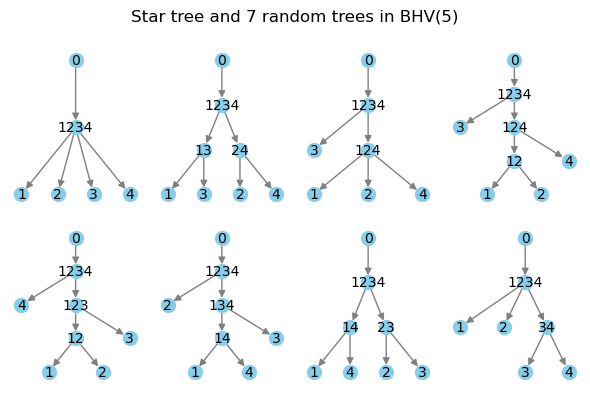

In [3]:
# BHV space only defined with N >= 4
bhv5 = TreeSpace(n_labels=5)

# This is the star tree, with no interior splits
star_tree = Tree((), [], n_labels=5)

# Let's make 7 more random trees
N_RANDOM_TREES = 7
random_trees = bhv5.random_point(N_RANDOM_TREES)

trees = [star_tree] + random_trees

fig, axes = plt.subplots(2, N_RANDOM_TREES // 2 + 1, figsize=(6, 4))
axes = axes.flatten()
for i, tree in enumerate(trees):
    # root_id is just for visualisation, so we know how to hang the tree
    tree.plot(root_id=0, ax=axes[i])
plt.suptitle(f"Star tree and {N_RANDOM_TREES} random trees in BHV(5)")
plt.tight_layout()
plt.show()

## 3. Geodesic

Here is a nice website to visualise how three orthants are related https://plewis.github.io/applets/bhvspace/ and how points in those orthants are connected by geodesics (distance-minimising paths). The star tree is located at the origin.

In BHV(5) there are four different types of geodesics:
- inner-orthant, meaning just interior split lengths change, but no splits are created and none are destroyed. This is the same as a straight line in Euclidean space
- edge-ending, meaning the geodesic ends on a lower-dimensional stratum, here a line or point. This means a split was destroyed (mutatis mutandum edge-starting geodesics start on a lower-dimensional stratum and enter a higher-dimensional one, creating a split)
- "straight" intra-orthant, in here a split is destroyed and another is created, and the geodesic traverses from a higher-dimensional plane, through the lower-dimensional stratum, and to another higher-dimensional stratum, but the line is straight (in BHV(5): 2d->1d->2d)
- "bent" intra-orthant, in this one, the shortest path one passes through the origin (star tree)! and looks like a bent line. Here all interior splits dissapear and then new ones are created (in BHV(5): 2d->0d->2d)


### Inner-orthant geodesic

In [4]:
top_quadrant_topology = (Split({3, 4}, {0, 1, 2}), Split({0, 1}, {2, 3, 4}))

top_tree = Tree(top_quadrant_topology, [3, 1])
top_tree_shifted = Tree(top_quadrant_topology, [1, 4])

top_trees = [top_tree, top_tree_shifted]

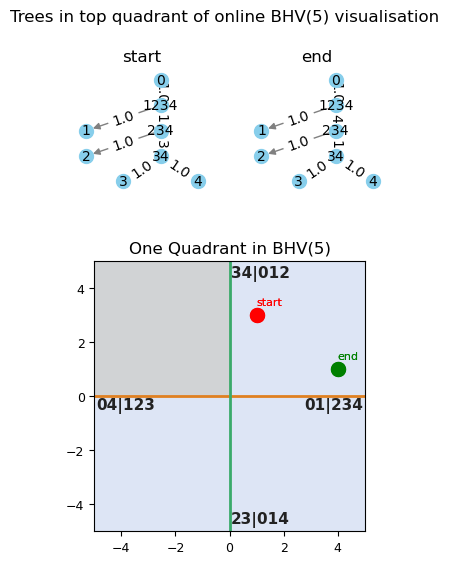

In [ ]:
fig = plt.figure(figsize=(4, 6), facecolor="white")
gs = GridSpec(2, max(2, 1), figure=fig, height_ratios=[1, 2.2], hspace=0.35, wspace=0.3)

top_trees = [top_tree, top_tree_shifted]
labels = ["start", "end"]
for i, tree in enumerate(top_trees):
    ax = fig.add_subplot(gs[0, i])
    tree.plot(root_id=0, show_edge_weights=True, ax=ax)
    ax.set_title(labels[i])

ax_quad = fig.add_subplot(gs[1, :])
_draw_quadrant_plot(ax_quad, max_xy=5)
colors = ["red", "green"]
for i, tree in enumerate(top_trees):
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])

plt.suptitle("Trees in top quadrant of online BHV(5) visualisation")
plt.show()

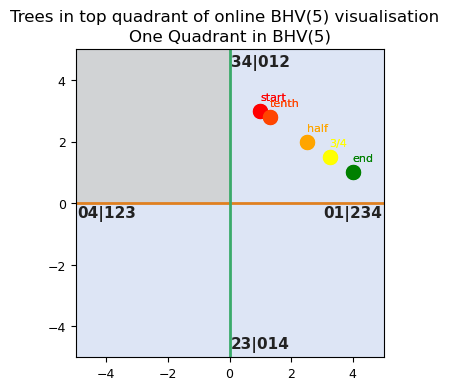

In [ ]:
## Geodesic same quadrant
geodesic = bhv5.metric.geodesic(top_trees[0], top_trees[-1])
beginning = geodesic(0)[0]
tenth = geodesic(0.1)[0]
halfway = geodesic(0.5)[0]
three_quarters = geodesic(0.75)[0]
end = geodesic(1)[0]

geodesic_trees = [beginning, tenth, halfway, three_quarters, end]
labels = ["start", "tenth", "half", "3/4", "end"]
colors = ["red", "orangered", "orange", "yellow", "green"]

# Let's draw the geodesic!!
fig, ax = plt.subplots(1, 1, figsize=(4, 4), facecolor="white")
_draw_quadrant_plot(ax, max_xy=5)
for i, tree in enumerate(geodesic_trees):
    _draw_tree_on_quadrant(ax, tree, c=colors[i], label=labels[i])
    _draw_tree_on_quadrant(ax, tree, c=colors[i], label=labels[i])

plt.suptitle("Trees in top quadrant of online BHV(5) visualisation")
plt.show()

### Intra-orthant "straight" geodesic

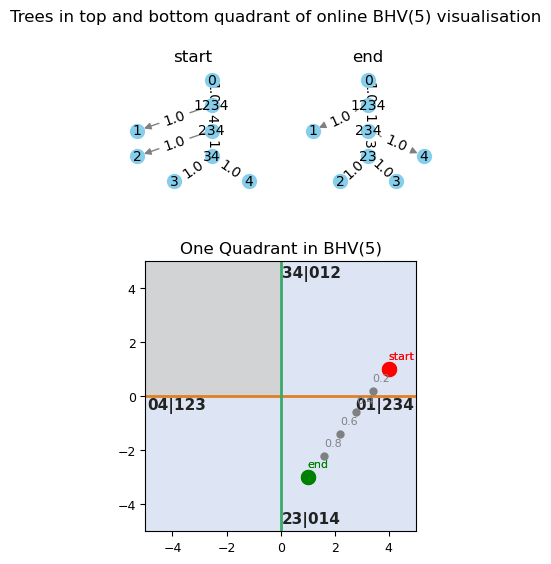

In [ ]:
bottom_right_quadrant_topology = (Split({2, 3}, {0, 1, 4}), Split({0, 1}, {2, 3, 4}))

top_tree = Tree(top_quadrant_topology, [1, 4])
bottom_tree = Tree(bottom_right_quadrant_topology, [3, 1])

trees = [top_tree, bottom_tree]

fig = plt.figure(figsize=(4, 6), facecolor="white")
gs = GridSpec(2, max(2, 1), figure=fig, height_ratios=[1, 2.2], hspace=0.35, wspace=0.3)

labels = ["start", "end"]
for i, tree in enumerate(trees):
    ax = fig.add_subplot(gs[0, i])
    tree.plot(root_id=0, show_edge_weights=True, ax=ax)
    ax.set_title(labels[i])

ax_quad = fig.add_subplot(gs[1, :])
_draw_quadrant_plot(ax_quad, max_xy=5)
colors = ["red", "green"]
for i, tree in enumerate(trees):
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])

### ADD GEODESIC TREES
geodesic = bhv5.metric.geodesic(top_tree, bottom_tree)
for i in range(1, 5):
    tree = geodesic(i / 5)[0]
    _draw_tree_on_quadrant(ax_quad, tree, ms=5, c="grey", label=str(i / 5))

plt.suptitle("Trees in top and bottom quadrant of online BHV(5) visualisation")
plt.show()

### Intra-orthant "bent" geodesic

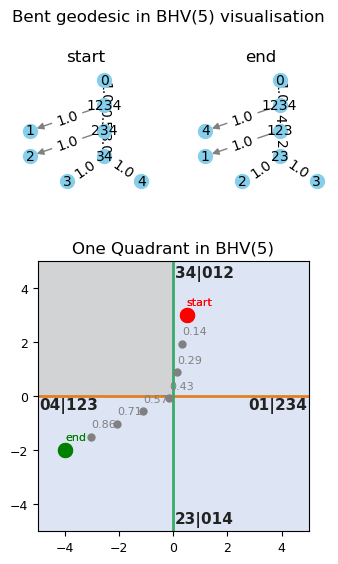

In [ ]:
bottom_left_quadrant_topology = (Split({2, 3}, {0, 1, 4}), Split({0, 4}, {1, 2, 3}))

top_tree = Tree(top_quadrant_topology, [3, 0.5])
bottom_tree = Tree(bottom_left_quadrant_topology, [2, 4])

trees = [top_tree, bottom_tree]

fig = plt.figure(figsize=(4, 6), facecolor="white")
gs = GridSpec(2, max(2, 1), figure=fig, height_ratios=[1, 2.2], hspace=0.35, wspace=0.3)

labels = ["start", "end"]
for i, tree in enumerate(trees):
    ax = fig.add_subplot(gs[0, i])
    tree.plot(root_id=0, show_edge_weights=True, ax=ax)
    ax.set_title(labels[i])

ax_quad = fig.add_subplot(gs[1, :])
_draw_quadrant_plot(ax_quad, max_xy=5)
colors = ["red", "green"]
for i, tree in enumerate(trees):
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])

### ADD GEODESIC TREES
geodesic = bhv5.metric.geodesic(top_tree, bottom_tree)
n_examples = 7
for i in range(1, n_examples):
    tree = geodesic(i / n_examples)[0]
    _draw_tree_on_quadrant(
        ax_quad, tree, ms=5, c="grey", label=f"{(i / n_examples):.2f}"
    )

plt.suptitle("Bent geodesic in BHV(5) visualisation")
plt.show()

## 3. Mean

Fréchet mean is computed in geodesic metric spaces (like BHV) via Sturm's algorithm. Since we do not have an `exp` in this space (undefined at origin), we can not use the typical gradient-descent approach. Instead, we use an iterative approach, which samples a point, computes the geodesic between that and the current mean estimate, walks a decreasing amount down that geodesic, rinses, and repeats. Since BHV is a CAT(0) (non-positively-curved) space, there are nice convergence guarantees.

Let's sample some random trees and keep only the ones in our three quadrants that we have decided to visualize!

In [38]:
valid_trees = []
while len(valid_trees) < 10:
    random_tree = bhv5.random_point()
    tree_good = True
    for split in random_tree.topology.splits:
        small_split = split.part1 if len(split.part1) == 2 else split.part2
        if small_split not in ({0, 1}, {0, 4}, {3, 4}, {2, 3}):
            tree_good = False

    if tree_good:
        random_tree.lengths = 3 * random_tree.lengths
        valid_trees.append(random_tree)

print(f"Found {len(valid_trees)} valid trees")

Found 10 valid trees


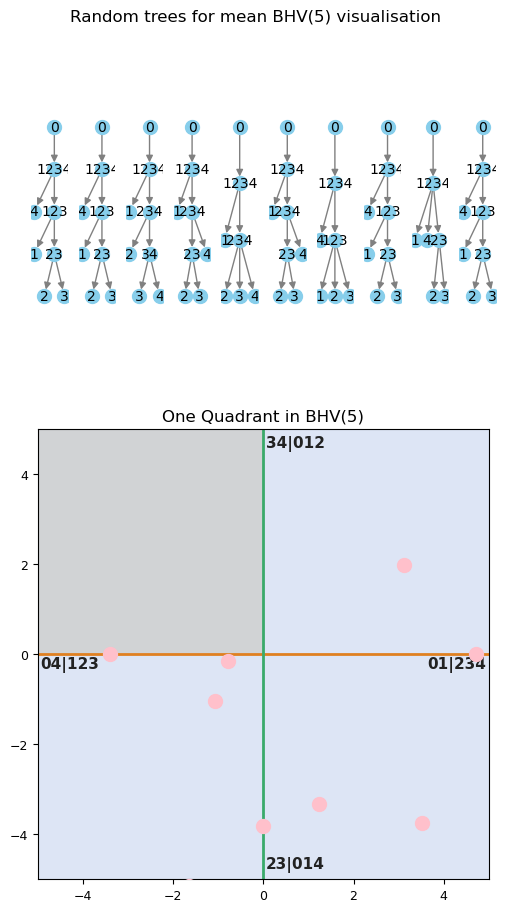

In [40]:
fig = plt.figure(figsize=(6, 10), facecolor="white")
gs = GridSpec(
    2, len(valid_trees), figure=fig, height_ratios=[1, 2.2], hspace=0.35, wspace=0.3
)

for i, tree in enumerate(valid_trees):
    ax = fig.add_subplot(gs[0, i])
    tree.plot(root_id=0, show_edge_weights=False, ax=ax)

ax_quad = fig.add_subplot(gs[1, :])
_draw_quadrant_plot(ax_quad, max_xy=5)
for i, tree in enumerate(valid_trees):
    _draw_tree_on_quadrant(ax_quad, tree, c="pink")


plt.suptitle("Random trees for mean BHV(5) visualisation")
plt.show()

In [ ]:
## Compute the mean!!


### TreeTopology tests

In [ ]:
# ## Empty split not allowed
# illegal_empty_topology = (Split({}, {0, 1, 2, 3, 4}), Split({0, 1}, {2, 3, 4}))
# expected_error_message = "Empty splits like .* are not allowed."

# with pytest.raises(ValueError, match=expected_error_message):
#     TreeTopology(illegal_empty_topology)

# ## Singleton split not allowed
# illegal_pendant_topology = (Split({3}, {0, 4, 1, 2}), Split({0, 1}, {2, 3, 4}))
# expected_error_message = "Pendant edges / singleton splits like .* are not allowed."

# with pytest.raises(ValueError, match=expected_error_message):
#     TreeTopology(illegal_pendant_topology)

# ## This one is fine
# legal_topology = (Split({3, 4}, {0, 1, 2}), Split({0, 1}, {2, 3, 4}))
# legal_tt = TreeTopology(legal_topology)

# assert legal_tt.splits == legal_topology
# assert legal_tt.n_labels == 5

# ## Star tree should work
# star_tree_topology = ()
# star_tt = TreeTopology(star_tree_topology, n_labels=5)

# assert star_tt.splits == star_tree_topology
# assert star_tt.n_labels == 5

### TreeTopology tests

### TreeSpace tests

In [ ]:
# # BHV space only defined with N >= 4
# expected_error_message = "BHV space only defined for N >= 4.*"
# with pytest.raises(ValueError, match=expected_error_message):
#     TreeSpace(n_labels=2)

# # This is fine.
# bhv5 = TreeSpace(n_labels=5)

# # Make random point and check if belongs in space
# random_tree = bhv5.random_point()
# assert bhv5.belongs(random_tree)

# # Check handling of non-tree
# assert not bhv5.belongs("imposter")

# # make random point in other space and make sure it doesn't belong
# bhv7 = TreeSpace(n_labels=7)
# assert not bhv7.belongs(random_tree)

### BHVMetric tests

https://plewis.github.io/applets/bhvspace/

^^ v helpful for visualisation and test creation

In [ ]:
# # These trees can have max two compatible splits out of ten total.
# bhv5 = TreeSpace(n_labels=5)

# top_quartile_topology = (Split({3, 4}, {0, 1, 2}), Split({0, 1}, {2, 3, 4}))
# left_quartile_topology = (Split({2, 3}, {0, 1, 4}), Split({0, 4}, {3, 1, 2}))
# right_quartile_topology = (Split({2, 3}, {0, 1, 4}), Split({0, 1}, {2, 3, 4}))
# right_stratum_topology = (Split({0, 1}, {2, 3, 4}),)
# lengths = gs.array([3, 1])

# top_tree = Tree(top_quartile_topology, lengths)
# top_tree_shifted = Tree(top_quartile_topology, lengths + 1)
# right_tree = Tree(right_quartile_topology, lengths)
# mirrored_left_tree = Tree(left_quartile_topology, lengths)
# halfway_tree_right = Tree(right_stratum_topology, [1])
# star_tree = Tree((), [], n_labels=5)

# ## Distance same quadrant
# dist = bhv5.metric.dist(top_tree, top_tree_shifted)
# expected_dist = 2**0.5
# assert gs.abs(dist - expected_dist) < gs.atol

# ## Distance different quadrant, vertical line
# dist = bhv5.metric.dist(top_tree, right_tree)
# expected_dist = 6
# assert gs.abs(dist - expected_dist) < gs.atol

# ## Distance different quadrant, diagonal line
# dist = bhv5.metric.dist(top_tree_shifted, right_tree)
# expected_dist = (1 + 7**2) ** 0.5
# assert gs.abs(dist - expected_dist) < gs.atol

# ## Distance different quadrant, geodesic through origin
# dist = bhv5.metric.dist(top_tree, mirrored_left_tree)
# expected_dist = 2 * (1 + 3**2) ** 0.5
# assert gs.abs(dist - expected_dist) < gs.atol

# ## Geodesic same quadrant
# geodesic = bhv5.metric.geodesic(top_tree, top_tree_shifted)
# beginning = geodesic(0)
# halfway = geodesic(0.5)
# end = geodesic(1)
# expected_halfway = Tree(top_quartile_topology, lengths + 0.5)
# assert beginning.equal(top_tree)
# assert halfway.equal(expected_halfway)
# assert end.equal(top_tree_shifted)

# ## Geodesic different quadrant
# geodesic = bhv5.metric.geodesic(top_tree, right_tree)
# beginning = geodesic(0)
# halfway = geodesic(0.5)
# end = geodesic(1)
# assert beginning.equal(top_tree)
# assert halfway.equal(halfway_tree_right)
# assert end.equal(right_tree)

# ## Geodesic different quadrant, geodesic through origin
# geodesic = bhv5.metric.geodesic(top_tree, mirrored_left_tree)
# beginning = geodesic(0)
# less_than_halfway = geodesic(0.3)
# halfway = geodesic(0.5)
# more_than_halfway = geodesic(0.7)
# end = geodesic(1)
# expected_less_than_halfway = Tree(top_quartile_topology, [1.2, 0.4])
# expected_more_than_halfway = Tree(left_quartile_topology, [1.2, 0.4])
# assert beginning.equal(top_tree)
# assert less_than_halfway.equal(expected_less_than_halfway)
# assert halfway.equal(star_tree)
# assert more_than_halfway.equal(expected_more_than_halfway)
# assert end.equal(mirrored_left_tree)

# ## Geodesic illegal actions
# geodesic = bhv5.metric.geodesic(top_tree, mirrored_left_tree)

# expected_error_message = "Geodesics only exist for 0<=t<=1.*"
# with pytest.raises(ValueError, match=expected_error_message):
#     geodesic(-1)
# with pytest.raises(ValueError, match=expected_error_message):
#     geodesic(1.1)

## Visualisation

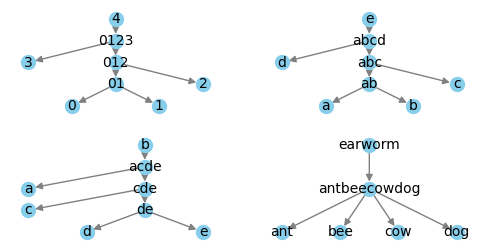

In [ ]:
# top_tree = Tree(top_quartile_topology, lengths)
# top_tree_shifted = Tree(top_quartile_topology, lengths + 1)
# right_tree = Tree(right_quartile_topology, lengths)
# mirrored_left_tree = Tree(left_quartile_topology, lengths)
# halfway_tree_right = Tree(right_stratum_topology, [1])
# star_tree = Tree((), [], n_labels=5)

# fig, axes = plt.subplots(2, 2, figsize=(6, 3))
# star_tree._to_networkx()
# top_tree.plot(ax=axes[0][0])
# top_tree_shifted.plot(root_id=4, leaf_labels=["a", "b", "c", "d", "e"], ax=axes[0][1])
# top_tree_shifted.plot(root_id=1, leaf_labels=["a", "b", "c", "d", "e"], ax=axes[1][0])
# star_tree.plot(
#     root_id=4, leaf_labels=["ant", "bee", "cow", "dog", "earworm"], ax=axes[1][1]
# )
# plt.show()